# HW 1

News topic classification on lenta-ru-news with bag-of-words and TF-IDF

## Environment setup


Before running this notebook:
1. Install [uv](https://docs.astral.sh/uv/getting-started/installation/)
2. Run `uv sync --group hw_1` from the repo root to install all needed deps
3. Use `.venv` created by uv to run jupyter kernel

## Notebook setup

Let's set working directory to repo root:

In [1]:
import os

while os.getcwd().split("/")[-1] != "itmo-ai-talent-hub-dl-and-nlp-course":
    os.chdir("..")

os.getcwd()

'/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course'

Let's import everything we need:

In [2]:
import os
import re
import math
import random
import string
import warnings
import multiprocessing

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from joblib import Parallel, delayed, dump

import razdel
import pymorphy3
from corus import load_lenta
from tqdm.auto import tqdm

/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's ignore warnings to keep the output clean:

In [3]:
warnings.filterwarnings("ignore")

Let's fix the random seed for reproducibility:

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Let's check how many CPU cores we have for parallel processing:

In [5]:
N_JOBS = multiprocessing.cpu_count()
print(f"CPU cores: {N_JOBS}")

CPU cores: 12


Let's define paths for data caching — we save intermediate results to avoid re-running expensive steps:

In [ ]:
RAW_DATA_PATH = os.path.join("data", "raw",      "hw_1", "lenta-ru-news.csv.gz")
INTERIM_PATH  = os.path.join("data", "interim",  "hw_1", "df_preprocessed.parquet")
PROCESSED_DIR = os.path.join("data", "processed","hw_1")

## Data Loading

Let's load the lenta-ru-news dataset using corus — it contains ~739k news articles with title, text and topic:

In [ ]:
if not os.path.exists(RAW_DATA_PATH):
    import urllib.request
    url = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"
    print(f"Downloading dataset to {RAW_DATA_PATH}...")
    os.makedirs(os.path.dirname(RAW_DATA_PATH), exist_ok=True)
    urllib.request.urlretrieve(url, RAW_DATA_PATH)
    print("Done.")
else:
    print(f"Dataset already exists at {RAW_DATA_PATH}")

Dataset already exists at data/raw/hw_1/lenta-ru-news.csv.gz


In [ ]:
if not os.path.exists(INTERIM_PATH):
    records = []
    for record in load_lenta(RAW_DATA_PATH):
        records.append({"title": record.title, "text": record.text, "topic": record.topic})
    df_full = pd.DataFrame(records)
    print(f"Total records loaded: {len(df_full):,}")
    display(df_full.head())

## Data Preparation

### Sampling

Let's take a stratified 100k sample from the full dataset — each topic keeps its original share so rare topics are not accidentally dropped. 100k is enough for reliable training while keeping preprocessing and CV time manageable:

In [ ]:
if not os.path.exists(INTERIM_PATH):
    SAMPLE_SIZE = 100_000

    df_full = df_full.dropna(subset=["title", "text", "topic"])
    df_full = df_full[df_full["text"].str.strip().astype(bool)].reset_index(drop=True)

    print(f"Records after cleaning nulls/empties: {len(df_full):,}")
    print(f"Number of unique topics: {df_full['topic'].nunique()}")
    print()
    print(df_full["topic"].value_counts())

In [ ]:
if not os.path.exists(INTERIM_PATH):
    samples = []
    for topic, group in df_full.groupby("topic"):
        n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_full)))
        samples.append(group.sample(n=n, random_state=RANDOM_STATE))

    df = pd.concat(samples).reset_index(drop=True)
    if len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

    print(f"Sampled dataset size: {len(df):,}")
    print()
    print(df["topic"].value_counts())

In [ ]:
if os.path.exists(INTERIM_PATH):
    df = pd.read_parquet(INTERIM_PATH)
    print(f"Loaded from {INTERIM_PATH}: {len(df):,} rows")

Loaded from data/interim/hw_1/df_preprocessed.parquet: 99,405 rows


### EDA

Let's explore the data to understand class balance, text lengths and topic characteristics:

In [12]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print(df[["text_len", "word_count"]].describe())

           text_len    word_count
count  99405.000000  99405.000000
mean    1320.143826    178.474010
std      491.280662     66.043233
min        3.000000      1.000000
25%      976.000000    132.000000
50%     1254.000000    170.000000
75%     1597.000000    216.000000
max     3840.000000    445.000000


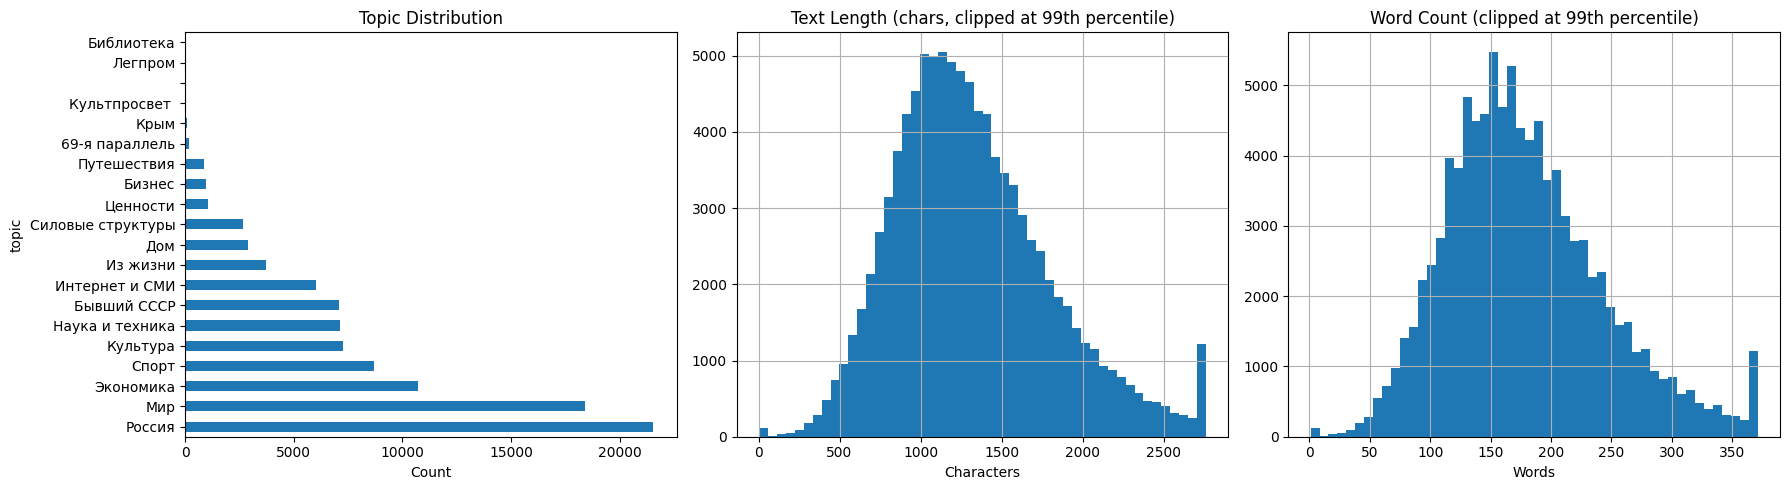

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Topic distribution
df["topic"].value_counts().plot.barh(ax=axes[0])
axes[0].set_title("Topic Distribution")
axes[0].set_xlabel("Count")

# Text length distribution
df["text_len"].clip(upper=df["text_len"].quantile(0.99)).hist(bins=50, ax=axes[1])
axes[1].set_title("Text Length (chars, clipped at 99th percentile)")
axes[1].set_xlabel("Characters")

# Word count distribution
df["word_count"].clip(upper=df["word_count"].quantile(0.99)).hist(bins=50, ax=axes[2])
axes[2].set_title("Word Count (clipped at 99th percentile)")
axes[2].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [ ]:
# Normalised class distribution
print('Topic share (%):')
print((df['topic'].value_counts(normalize=True) * 100).round(2).to_string())

Topic share (%):
topic
Россия               21.68
Мир                  18.54
Экономика            10.77
Спорт                 8.75
Культура              7.29
Наука и техника       7.18
Бывший СССР           7.13
Интернет и СМИ        6.06
Из жизни              3.75
Дом                   2.92
Силовые структуры     2.66
Ценности              1.06
Бизнес                0.98
Путешествия           0.87
69-я параллель        0.17
Крым                  0.09
Культпросвет          0.05
                      0.03
Легпром               0.02
Библиотека            0.01


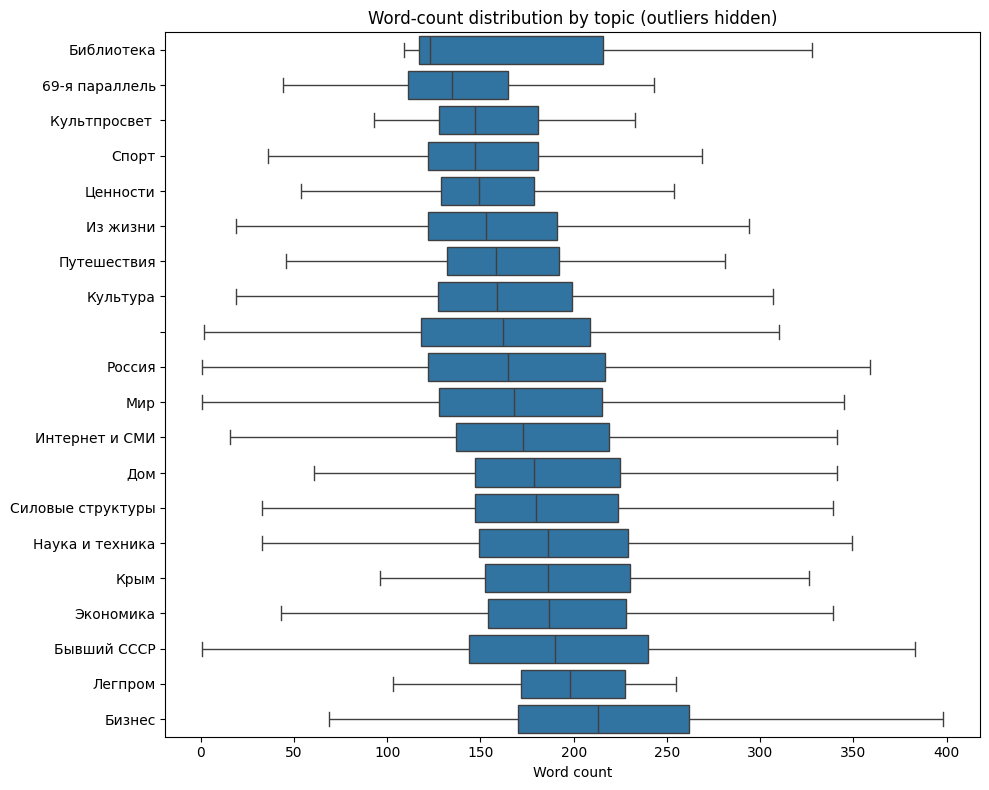

In [ ]:
# Word-count distribution per topic
topic_order = df.groupby('topic')['word_count'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(
    data=df,
    y='topic', x='word_count',
    order=topic_order,
    showfliers=False,
    ax=ax,
)
ax.set_title('Word-count distribution by topic (outliers hidden)')
ax.set_xlabel('Word count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

We can see that the dataset is heavily imbalanced — "Россия" dominates with 21.7% of all articles, while the smallest topics ("Библиотека", "Легпром") have less than 0.05%. Word count distributions vary across topics: median is around 170 words, with most articles in the 130–216 range. There are a few very rare/empty topics (unnamed topic with 0.03%) that will likely be impossible to classify well

### Data quality check

Let's check for duplicates, conflicting labels and bad texts before preprocessing:

In [16]:
# Duplicates
n_dup = df.duplicated("text").sum()
print(f"Duplicate texts: {n_dup}")

# Conflicting labels: same text, different topic
n_conflict = (df.groupby("text")["topic"].nunique() > 1).sum()
print(f"Texts with conflicting topic labels: {n_conflict}")

# Drop duplicates, keeping first occurrence
df = df.drop_duplicates("text").reset_index(drop=True)
print(f"After dedup: {len(df):,}")

Duplicate texts: 0
Texts with conflicting topic labels: 0
After dedup: 99,405


In [ ]:
# Bad texts: empty, only punctuation/symbols, only digits
def is_bad_text(s):
    s0 = s.strip()
    if len(s0) == 0:
        return True
    if re.fullmatch(r"[^a-zA-Za-z\u0400-\u04FF]+", s0):
        return True
    if re.fullmatch(r"\d+", s0):
        return True
    return False

bad_mask = df["text"].apply(is_bad_text)
print(f"Bad texts: {bad_mask.sum()} ({bad_mask.mean():.2%})")
df = df[~bad_mask].reset_index(drop=True)

Bad texts: 0 (0.00%)


### Preprocessing Pipeline

Let's combine title and body, then process each article through these steps:

- **Lowercase** — normalizes case variation
- **Remove URLs and emails** — pure noise for topic classification
- **Remove non-alphabetic characters** — digits and punctuation don't carry topical meaning
- **Tokenize** with `razdel` — designed for Russian, handles abbreviations and punctuation edge cases better than a simple split
- **Lemmatize** with `pymorphy3` — Russian morphology is rich: a single word can appear in 10+ surface forms, so lemmatization maps them all to one dictionary form, shrinking the vocabulary and improving generalization. We chose it over stemming because pymorphy3 uses a real morphological dictionary and produces clean base forms, while rule-based Russian stemmers tend to produce noisy cuts
- **Drop tokens shorter than 2 characters** — removes stray single-letter fragments

For speed, preprocessing runs in parallel with `joblib` — one `MorphAnalyzer` per worker process to amortize initialization cost:

In [ ]:
# Length outliers (clip at 99.5th percentile)
upper = df["word_count"].quantile(0.995)
too_long = df["word_count"] > upper
print(f"Texts longer than {upper:.0f} words: {too_long.sum()}")
df = df[~too_long].reset_index(drop=True)
print(f"Clean dataset: {len(df):,}")

Texts longer than 396 words: 491
Clean dataset: 98,914


In [19]:
# Compile regex patterns once (main process only)
RE_URL      = re.compile(r"https?://\S+|www\.\S+")
RE_EMAIL    = re.compile(r"\S+@\S+\.\S+")
RE_NONALPHA = re.compile(r"[^a-zA-Z\u0400-\u04FF\s]")
RE_MULTISPACE = re.compile(r"\s+")


def preprocess_text(text, morph=None):
    """Full preprocessing pipeline. Uses module-level morph if not provided."""
    if morph is None:
        morph = pymorphy3.MorphAnalyzer()
    text = text.lower()
    text = RE_URL.sub(" ", text)
    text = RE_EMAIL.sub(" ", text)
    text = RE_NONALPHA.sub(" ", text)
    text = RE_MULTISPACE.sub(" ", text).strip()
    tokens = [token.text for token in razdel.tokenize(text)]
    lemmas = [morph.parse(tok)[0].normal_form for tok in tokens if len(tok) >= 2]
    return " ".join(lemmas)


def preprocess_chunk(texts):
    """Worker function: one MorphAnalyzer per chunk (amortises ~30 MB init cost)."""
    import re, razdel, pymorphy3  # re-import inside worker (spawn on macOS)
    _morph    = pymorphy3.MorphAnalyzer()
    _url      = re.compile(r"https?://\S+|www\.\S+")
    _email    = re.compile(r"\S+@\S+\.\S+")
    _nonalpha = re.compile(r"[^a-zA-Z\u0400-\u04FF\s]")
    _multi    = re.compile(r"\s+")
    out = []
    for text in texts:
        text = text.lower()
        text = _url.sub(" ", text)
        text = _email.sub(" ", text)
        text = _nonalpha.sub(" ", text)
        text = _multi.sub(" ", text).strip()
        tokens = [t.text for t in razdel.tokenize(text)]
        lemmas = [_morph.parse(tok)[0].normal_form for tok in tokens if len(tok) >= 2]
        out.append(" ".join(lemmas))
    return out


# Smoke-test
_sample = preprocess_text("Хакеры раскрыли планы: https://example.com и email@test.ru")
print("Smoke test:", _sample)

Smoke test: хакер раскрыть план


In [ ]:
if not os.path.exists(INTERIM_PATH):
    df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    texts = df["full_text"].tolist()

    chunk_size = math.ceil(len(texts) / N_JOBS)
    chunks = [texts[i : i + chunk_size] for i in range(0, len(texts), chunk_size)]

    print(f"Parallel preprocessing: {len(texts):,} texts across {len(chunks)} workers ...")
    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(preprocess_chunk)(chunk) for chunk in tqdm(chunks, desc="Chunks")
    )
    df["processed_text"] = [t for chunk in results for t in chunk]
    print("Done.")

In [ ]:
if not os.path.exists(INTERIM_PATH):
    empty_mask = df["processed_text"].str.strip() == ""
    print(f"Empty texts after preprocessing: {empty_mask.sum()}")
    df = df[~empty_mask].reset_index(drop=True)
    print(f"Final dataset size: {len(df):,}")

In [ ]:
if not os.path.exists(INTERIM_PATH):
    os.makedirs(os.path.dirname(INTERIM_PATH), exist_ok=True)
    df.to_parquet(INTERIM_PATH, index=False)
    print(f"Saved to {INTERIM_PATH}")

## Dummy Baseline

Let's start with a most-frequent-class predictor to set the lower bound — any real model should beat it by a wide margin. We can see that dummy accuracy is 0.217 (just the share of "Россия") and macro F1 is 0.018 because it only predicts one class

In [ ]:
if os.path.exists(os.path.join(PROCESSED_DIR, "train.parquet")):
    train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
    val_df   = pd.read_parquet(os.path.join(PROCESSED_DIR, "val.parquet"))
    test_df  = pd.read_parquet(os.path.join(PROCESSED_DIR, "test.parquet"))
    X_train, y_train = train_df["processed_text"], train_df["topic"]
    X_val,   y_val   = val_df["processed_text"],   val_df["topic"]
    X_test,  y_test  = test_df["processed_text"],  test_df["topic"]
    print("Loaded splits from disk")
else:
    X = df["processed_text"]
    y = df["topic"]
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
    )
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    for name, X_part, y_part in [("train", X_train, y_train),
                                  ("val",   X_val,   y_val),
                                  ("test",  X_test,  y_test)]:
        pd.DataFrame({"processed_text": X_part, "topic": y_part}).to_parquet(
            os.path.join(PROCESSED_DIR, f"{name}.parquet"), index=False
        )

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Loaded splits from disk
Train: 59,643  Val: 19,881  Test: 19,881


In [ ]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)
print(f"Dummy baseline accuracy: {accuracy_score(y_val, y_pred_dummy):.4f}")
print(f"Dummy baseline F1 (macro): {f1_score(y_val, y_pred_dummy, average='macro', zero_division=0):.4f}")
print()

Dummy baseline accuracy: 0.2168
Dummy baseline F1 (macro): 0.0178



## Logistic Regression with Two Vectorizers

Let's train both pipelines (`Vectorizer → LogisticRegression`) with default hyperparameters first to see the baseline performance

### CountVectorizer

Let's start with raw token counts as features:

In [25]:
pipe_count = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
        n_jobs=N_JOBS,
    )),
])

pipe_count.fit(X_train, y_train)

y_pred_count = pipe_count.predict(X_val)
print("=== CountVectorizer + LogisticRegression ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_count):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_count, average='macro'):.4f}")
print()
print(classification_report(y_val, y_pred_count))

=== CountVectorizer + LogisticRegression ===
Accuracy: 0.8022
F1 (macro): 0.5862

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         6
   69-я параллель       1.00      0.47      0.64        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.63      0.38      0.47       195
      Бывший СССР       0.82      0.82      0.82      1417
              Дом       0.84      0.78      0.81       582
         Из жизни       0.60      0.56      0.58       746
   Интернет и СМИ       0.75      0.71      0.73      1205
             Крым       0.86      0.33      0.48        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.86      0.87      0.87      1449
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.81      0.79      3685
  Наука и техника       0.83      0.82      0.83      1427
      Путешествия       0.77    

### TF-IDF Vectorizer

Let's try TF-IDF to downweight common tokens and upweight distinctive ones. We can see that TF-IDF gives slightly higher accuracy (0.812 vs 0.802) but lower macro F1 (0.518 vs 0.586) — it struggles more with rare topics because TF-IDF downweights their few distinctive tokens too aggressively with default settings

In [26]:
pipe_tfidf = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
        n_jobs=N_JOBS,
    )),
])

pipe_tfidf.fit(X_train, y_train)

y_pred_tfidf = pipe_tfidf.predict(X_val)
print("=== TfidfVectorizer + LogisticRegression ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_tfidf):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_tfidf, average='macro'):.4f}")
print()
print(classification_report(y_val, y_pred_tfidf))

=== TfidfVectorizer + LogisticRegression ===
Accuracy: 0.8118
F1 (macro): 0.5182

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         6
   69-я параллель       0.00      0.00      0.00        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.89      0.16      0.27       195
      Бывший СССР       0.83      0.81      0.82      1417
              Дом       0.88      0.75      0.81       582
         Из жизни       0.67      0.53      0.59       746
   Интернет и СМИ       0.78      0.71      0.74      1205
             Крым       1.00      0.06      0.11        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.88      0.86      1449
          Легпром       0.00      0.00      0.00         3
              Мир       0.79      0.85      0.82      3685
  Наука и техника       0.83      0.86      0.84      1427
      Путешествия       0.84    

## Hyperparameter Tuning

Let's use `RandomizedSearchCV` with 20 random combinations, 3-fold stratified CV, scoring on macro F1. We tune:

- `max_features` — vocabulary size cap; controls noise from very rare tokens
- `ngram_range` — adding bigrams captures phrases like "центральный банк" that unigrams split apart
- `min_df` / `max_df` — drop tokens that are too rare (noise) or too common (no discriminative power)
- `C` — LR regularization strength; smaller C = more regularization, larger C = fits training data closer

Let's run separate searches for CountVec and TF-IDF with identical grids to make results comparable:

In [27]:
param_distributions = {
    "vectorizer__max_features": [10000, 30000, 50000, 100000, None],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [1, 2, 5],
    "vectorizer__max_df": [0.8, 0.9, 1.0],
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [28]:
search_count = RandomizedSearchCV(
    pipe_count,
    param_distributions,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
)

search_count.fit(X_train, y_train)

print(f"Best CountVectorizer F1 (macro): {search_count.best_score_:.4f}")
print(f"Best params: {search_count.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CountVectorizer F1 (macro): 0.5838
Best params: {'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 2, 'vectorizer__max_features': 50000, 'vectorizer__max_df': 0.8, 'classifier__C': 10.0}


In [29]:
search_tfidf = RandomizedSearchCV(
    pipe_tfidf,
    param_distributions,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
)

search_tfidf.fit(X_train, y_train)

print(f"Best TfidfVectorizer F1 (macro): {search_tfidf.best_score_:.4f}")
print(f"Best params: {search_tfidf.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best TfidfVectorizer F1 (macro): 0.5689
Best params: {'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 2, 'vectorizer__max_features': 50000, 'vectorizer__max_df': 0.8, 'classifier__C': 10.0}


In [30]:
# Compare on val
best_count = search_count.best_estimator_
best_tfidf = search_tfidf.best_estimator_

for name, model in [("CountVec (tuned)", best_count), ("TfidfVec (tuned)", best_tfidf)]:
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    print(f"{name}: Accuracy={acc:.4f}, F1(macro)={f1:.4f}")

CountVec (tuned): Accuracy=0.8070, F1(macro)=0.5951
TfidfVec (tuned): Accuracy=0.8241, F1(macro)=0.5958


## Test Evaluation and Error Analysis

Let's pick the best model based on validation F1 and evaluate it on the held-out test set:

In [31]:
# Pick best model
val_f1_count = f1_score(y_val, best_count.predict(X_val), average="macro")
val_f1_tfidf = f1_score(y_val, best_tfidf.predict(X_val), average="macro")

if val_f1_tfidf >= val_f1_count:
    best_model = best_tfidf
    best_name = "TfidfVectorizer"
else:
    best_model = best_count
    best_name = "CountVectorizer"

print(f"Best model: {best_name}")

# Test set evaluation
y_pred_test = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test F1 (macro): {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_test))

Best model: TfidfVectorizer
Test Accuracy: 0.8271
Test F1 (macro): 0.5692

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         5
   69-я параллель       0.80      0.24      0.36        34
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.60      0.28      0.38       196
      Бывший СССР       0.84      0.84      0.84      1417
              Дом       0.88      0.80      0.84       581
         Из жизни       0.67      0.59      0.62       746
   Интернет и СМИ       0.79      0.73      0.76      1206
             Крым       1.00      0.11      0.20        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.87      0.89      0.88      1450
          Легпром       0.00      0.00      0.00         3
              Мир       0.81      0.84      0.82      3686
  Наука и техника       0.85      0.86      0.85      1427
      Путешествия       0.84      0.60 

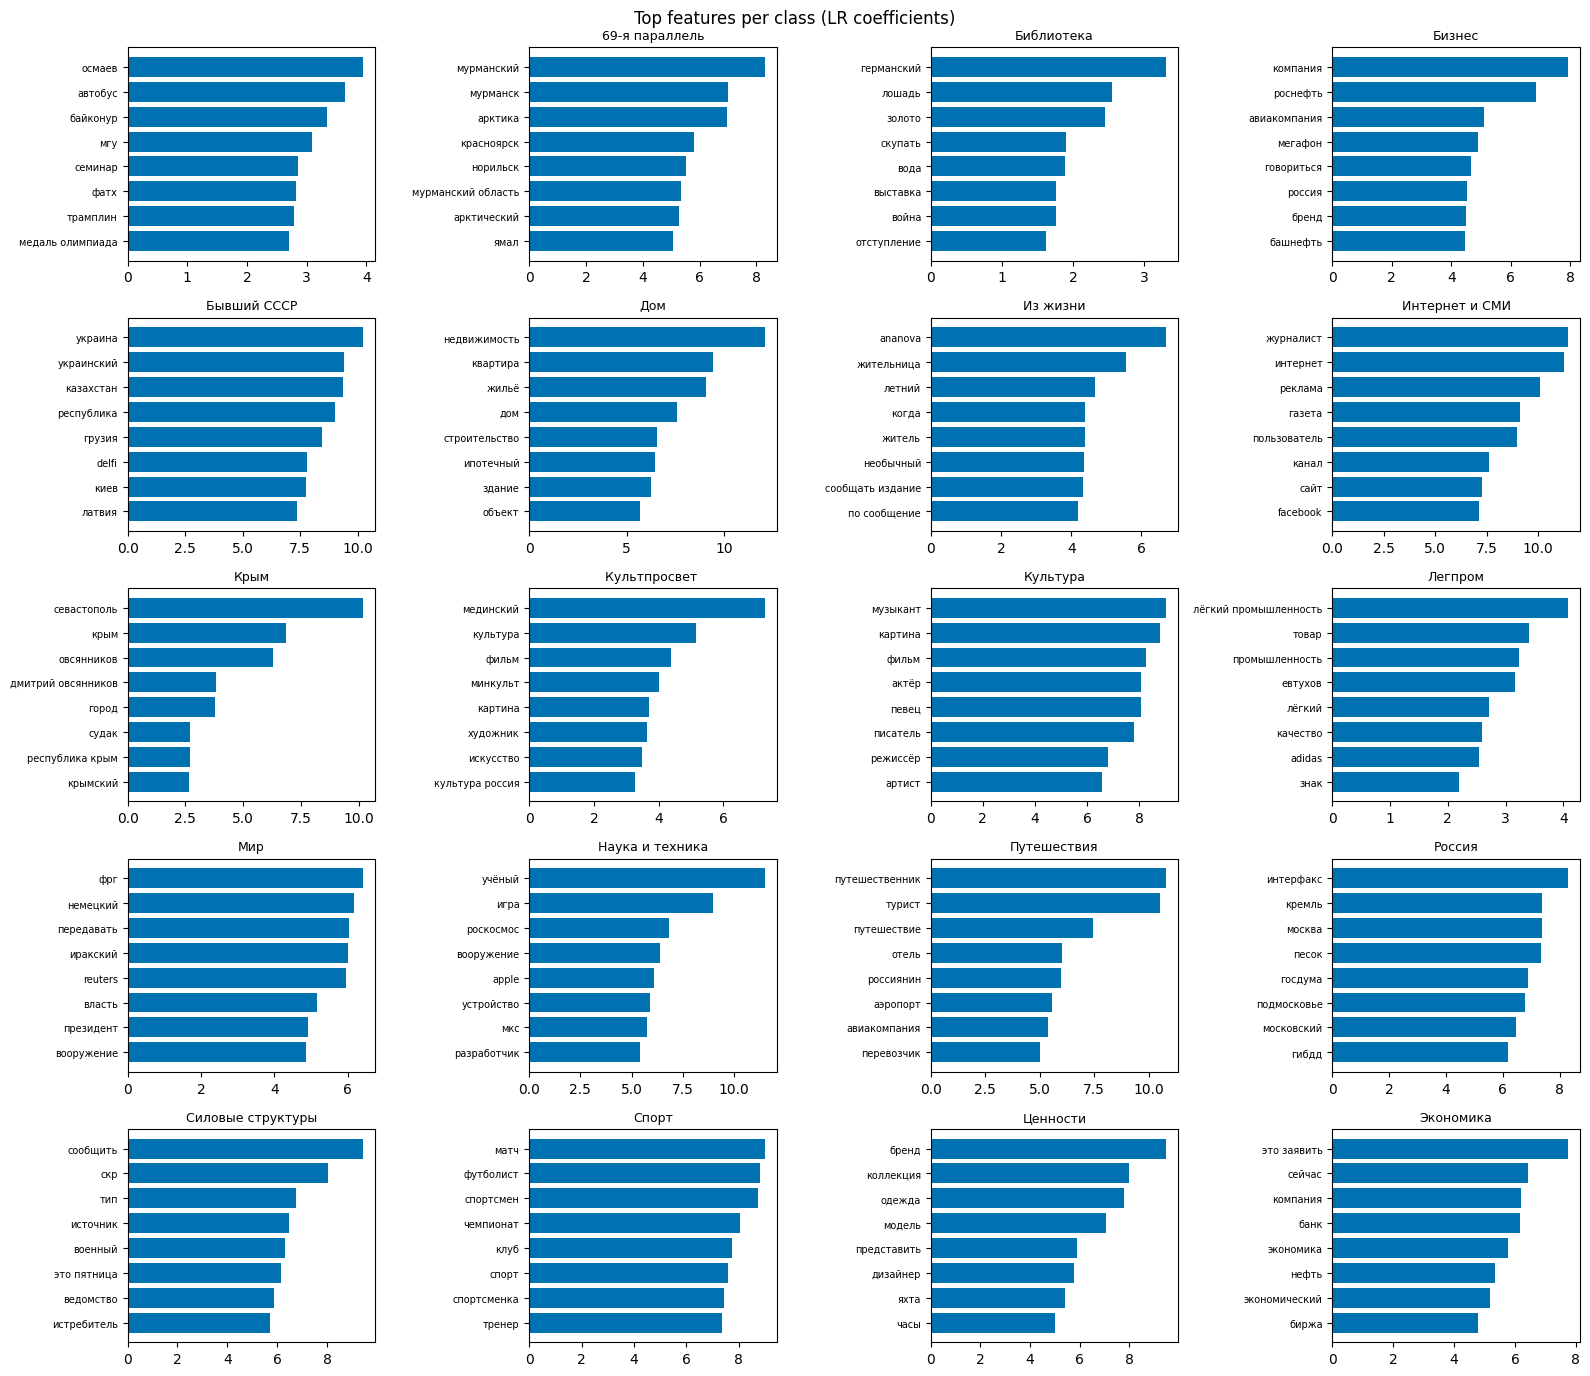

In [ ]:
# Top discriminative features per class (LR coefficients)
def top_features_per_class(pipe, top_k=8):
    vect = pipe.named_steps['vectorizer']
    clf  = pipe.named_steps['classifier']
    feat_names = np.array(vect.get_feature_names_out())
    classes    = clf.classes_
    coefs      = clf.coef_  # (n_classes, n_features)

    ncols = 4
    nrows = math.ceil(len(classes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8))
    axes = axes.flatten()

    for i, (cls, coef) in enumerate(zip(classes, coefs)):
        top_idx = np.argsort(coef)[-top_k:][::-1]
        feats = feat_names[top_idx][::-1]
        vals  = coef[top_idx][::-1]
        axes[i].barh(feats, vals, color='#0072b2')
        axes[i].set_title(cls, fontsize=9)
        axes[i].tick_params(axis='y', labelsize=7)
        axes[i].axvline(0, color='k', linewidth=0.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Top features per class (LR coefficients)', fontsize=12)
    plt.tight_layout()
    plt.show()


top_features_per_class(best_model)

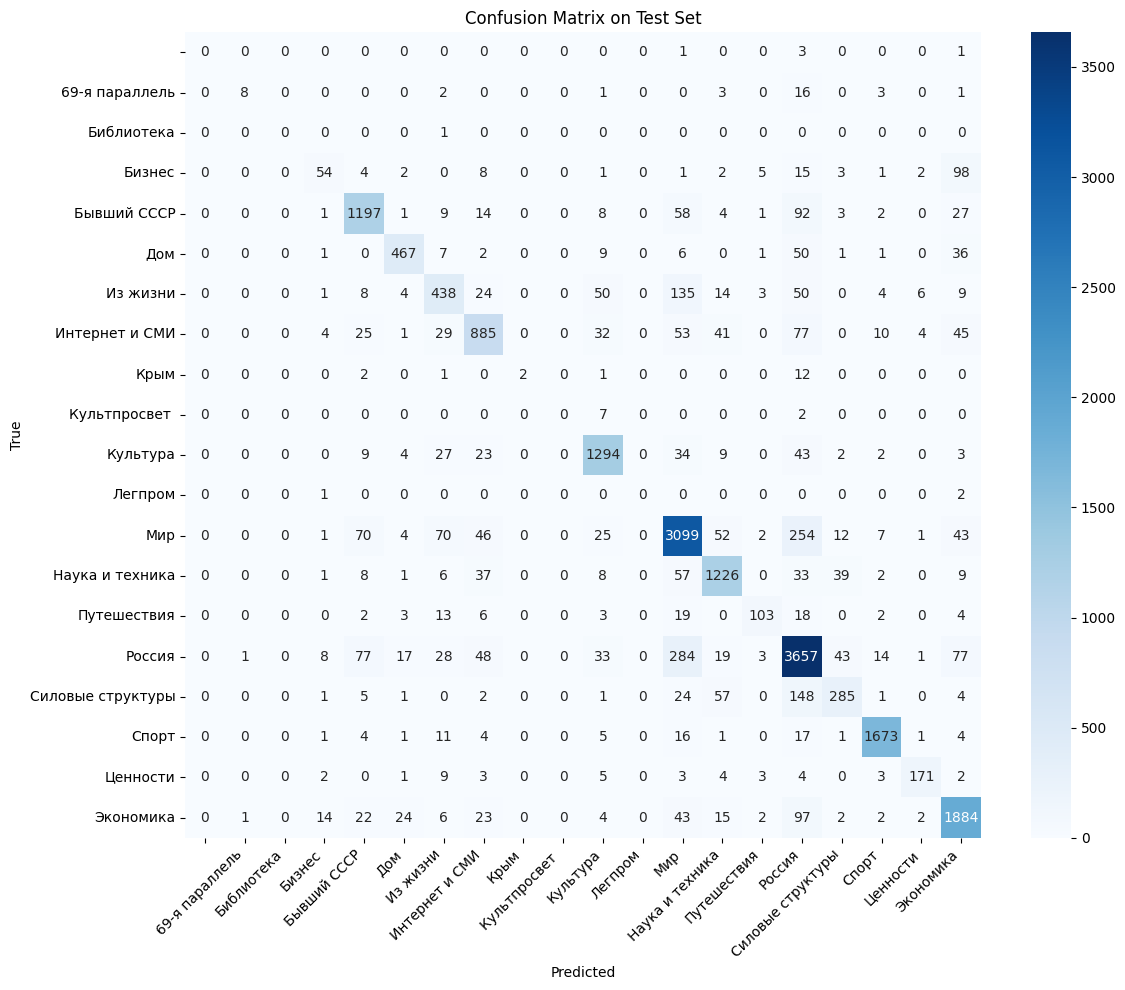

In [33]:
# Confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
# Error analysis
errors = pd.DataFrame({
    "text": X_test.values,
    "true_topic": y_test.values,
    "pred_topic": y_pred_test,
})
errors = errors[errors["true_topic"] != errors["pred_topic"]]

print(f"Total misclassified: {len(errors)} ({len(errors)/len(y_test):.1%})")
print()


confusion_pairs = errors.groupby(["true_topic", "pred_topic"]).size().sort_values(ascending=False)
print("Top 10 confusion pairs (true -> predicted):")
print(confusion_pairs.head(10))

Total misclassified: 3438 (17.3%)

Top 10 confusion pairs (true -> predicted):
true_topic         pred_topic 
Россия             Мир            284
Мир                Россия         254
Силовые структуры  Россия         148
Из жизни           Мир            135
Бизнес             Экономика       98
Экономика          Россия          97
Бывший СССР        Россия          92
Интернет и СМИ     Россия          77
Россия             Бывший СССР     77
                   Экономика       77
dtype: int64


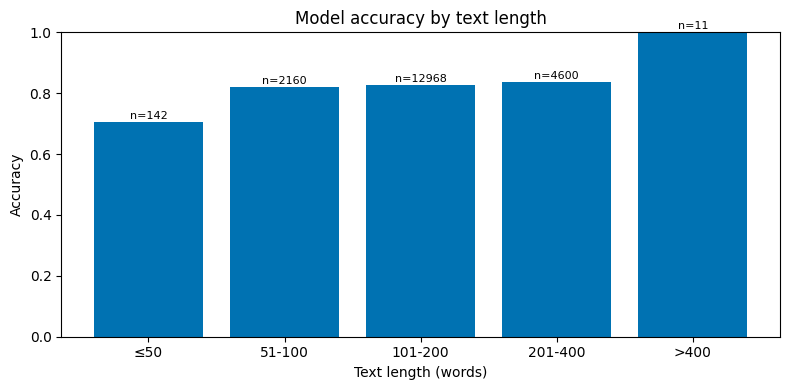

len_bin     n  accuracy
    ≤50   142  0.704225
 51-100  2160  0.821296
101-200 12968  0.825648
201-400  4600  0.837174
   >400    11  1.000000


In [ ]:
# Accuracy by text length bin
all_preds = pd.DataFrame({
    'text': X_test.values,
    'true': y_test.values,
    'pred': y_pred_test,
})
all_preds['len_words'] = all_preds['text'].str.split().str.len()
bins   = [0, 50, 100, 200, 400, 10_000]
labels = ['≤50', '51-100', '101-200', '201-400', '>400']
all_preds['len_bin'] = pd.cut(all_preds['len_words'], bins=bins, labels=labels)
all_preds['correct'] = all_preds['true'] == all_preds['pred']

grp = (
    all_preds.groupby('len_bin', observed=True)
    .agg(n=('correct', 'count'), accuracy=('correct', 'mean'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(grp['len_bin'].astype(str), grp['accuracy'], color='#0072b2')
for _, row in grp.iterrows():
    ax.text(str(row['len_bin']), row['accuracy'] + 0.01, f'n={row["n"]}',
            ha='center', fontsize=8)
ax.set_ylim(0, 1)
ax.set_xlabel('Text length (words)')
ax.set_ylabel('Accuracy')
ax.set_title('Model accuracy by text length')
plt.tight_layout()
plt.show()

print(grp.to_string(index=False))

## Conclusions

| Model | Val Accuracy | Val F1 (macro) | Test F1 (macro) |
|-------|-------------|----------------|----------------|
| Dummy (most\_frequent) | 0.217 | 0.018 | — |
| CountVec + LR | 0.802 | 0.586 | — |
| TfidfVec + LR | 0.812 | 0.518 | — |
| CountVec + LR (tuned) | 0.807 | 0.595 | — |
| **TfidfVec + LR (tuned)** | **0.824** | **0.596** | **0.569** |

We can see that TF-IDF with tuned hyperparameters gives the best result — tuning closed the gap between CountVec and TF-IDF on macro F1 while keeping TF-IDF's accuracy advantage. The confusion matrix shows that most errors happen between "Россия" ↔ "Мир" and "Силовые структуры" → "Россия" — these topics are semantically close, so the overlap is expected. Accuracy grows with text length (70% for ≤50 words → 84% for 200–400 words) because longer texts provide more distinctive tokens for the model to work with.

The top LR coefficients per class are intuitive: "Спорт" picks up "матч", "игра", "клуб"; "Экономика" gets "рубль", "банк", "цена". This confirms the model learns meaningful topic-word associations rather than noise.

Rare topics ("Библиотека", "Легпром", unnamed) with fewer than 10 samples per split have zero F1 — there is simply not enough data for the model to learn their patterns